In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle
from sklearn.ensemble import RandomForestRegressor
from utils.data_utils import evaluate_rf
import utils.cross_validation as cval
import random 
from shapely.geometry import box

In [ ]:

TEST_SIZE = 0.2
RANDOM_KEY = 21
BATCH_SIZE=16


df= pd.read_csv("fd_df_gc.csv")
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")


In [ ]:
sdf= pd.read_csv("sd_df_gc.csv")


In [ ]:
sdf.to_csv("sd_df_gc.csv", index=False)

In [ ]:
sdf.columns = sdf.columns.str.replace('_x$', '', regex=True)
sdf.columns = sdf.columns.str.replace('_y$', '', regex=True)

sdf = sdf.loc[:, ~sdf.columns.duplicated()]

In [ ]:
sdf['biome']

0        4
1        4
2        4
3        4
4        4
        ..
94172    4
94173    4
94174    4
94175    4
94176    4
Name: biome, Length: 94177, dtype: int64

In [ ]:
df['biome']

0        4
1        4
2        4
3        4
4        4
        ..
68626    4
68627    4
68628    4
68629    4
68630    4
Name: biome, Length: 68631, dtype: int64

In [ ]:
ecoregions.columns

Index(['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM',
       'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME',
       'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry'],
      dtype='str')

In [ ]:
ecoregions=ecoregions[['ECO_NAME', 'geometry']]

In [ ]:
df = df[~df['biome'].isin([13, 1, 2])]

df=cval.assign_spatial_groups(df, grid_size=1.0)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"  # WGS84
)

joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

In [ ]:
biome_dfs = {k: v for k, v in joined.groupby('biome')}

In [ ]:
biome_dfs[7]['ECO_NAME'].nunique()

3

In [ ]:
print(list(biome_dfs.keys()))

[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [ ]:
test_df=biome_dfs[3]

test_df.drop(columns=['BHAGE', 'managed',
       'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
       'lon_bin', 'lat_bin'], inplace=True)

In [ ]:
sets=list(set(test_df['ECO_NAME']))

In [ ]:
sets

['Western Great Lakes forests',
 'New England-Acadian forests',
 'Allegheny Highlands forests',
 nan]

In [ ]:
random.seed(RANDOM_KEY)
test_set = random.sample(sets, int(0.3 * len(sets)))

In [ ]:
test = test_df[test_df["ECO_NAME"].isin(test_set)]
train = test_df[~test_df["ECO_NAME"].isin(test_set)]

In [ ]:
y=['transformed npp', 'GC'] 

X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
y_train = np.column_stack([train['transformed npp'], train['GC']])

In [ ]:
y=['transformed npp', 'GC'] 

X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
y_test = np.column_stack([test['transformed npp'], test['GC']])

In [ ]:
fd_reg = RandomForestRegressor(random_state=RANDOM_KEY, n_jobs=2)
fd_reg.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


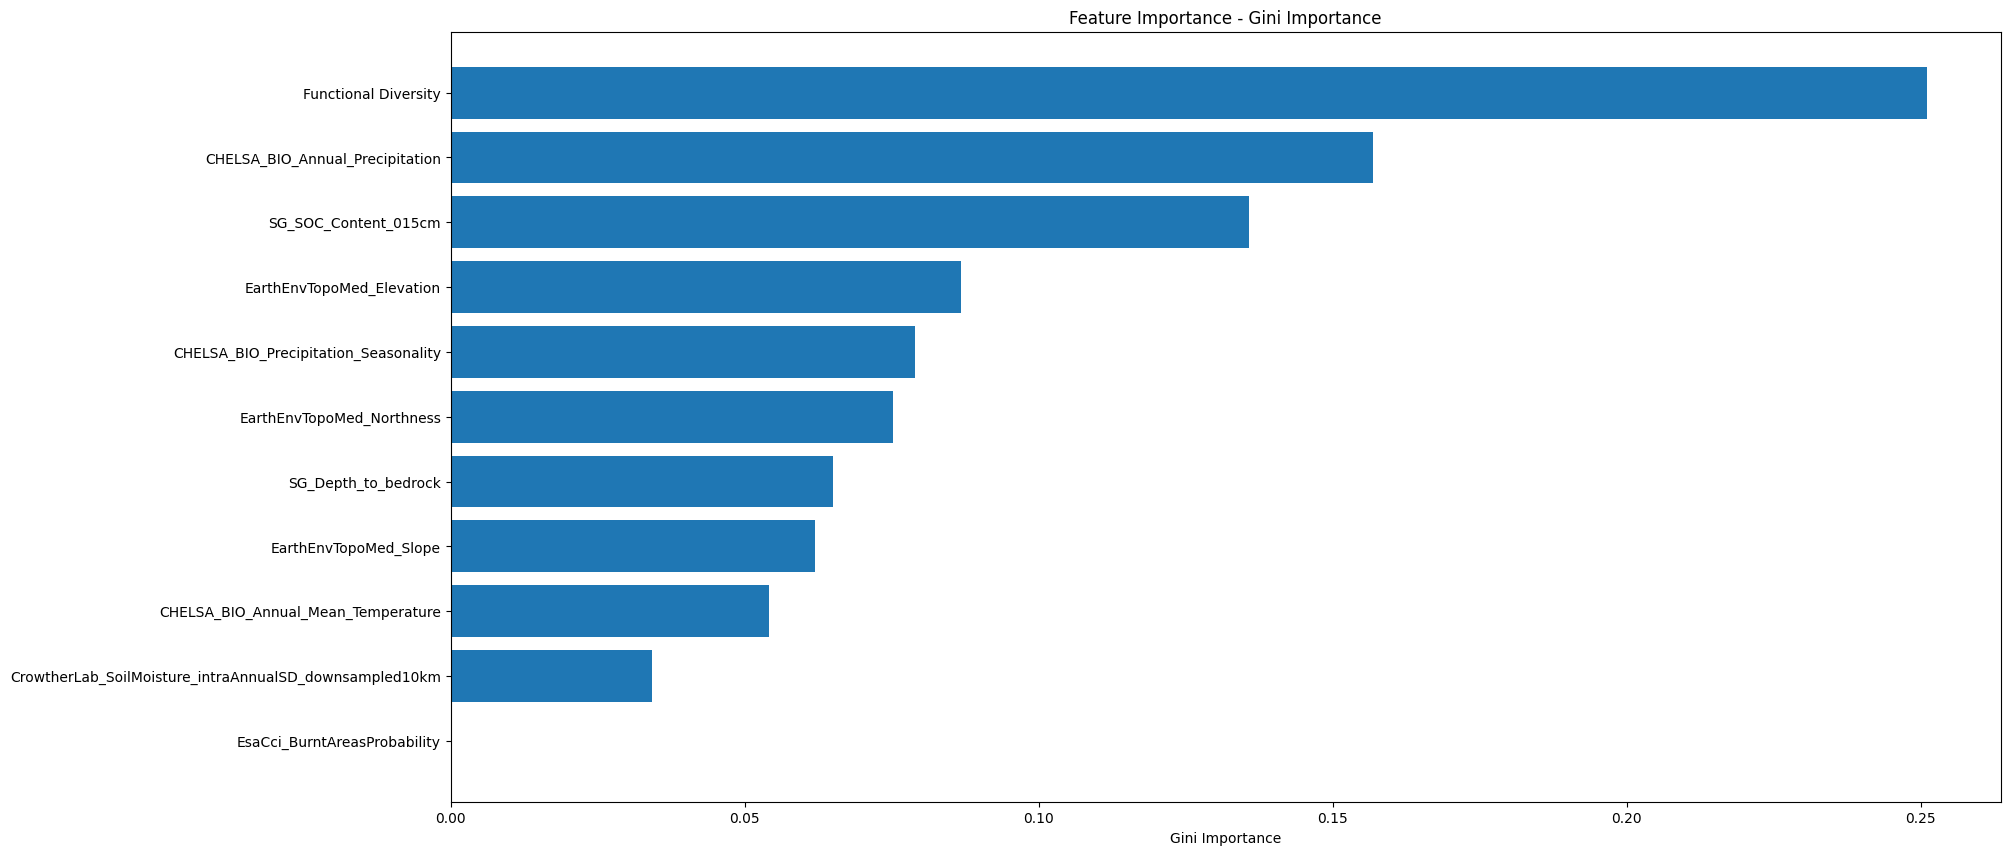

In [ ]:
evaluate_rf(X_test, y_test, fd_reg, feature_names=X_train.columns, importance= True, div_type= 'f')


In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from utils.data_utils import evaluate_rf
import utils.cross_validation as cval
import random 
from shapely.geometry import box

import threading

def train_test_split(sub_df, random_key, test_size):
    sub_df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin'], inplace=True)

    sets=list(set(sub_df['ECO_NAME']))

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['transformed npp', 'GC'] 

    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = np.column_stack([train['transformed npp'], train['GC']])

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = np.column_stack([test['transformed npp'], test['GC']])

    return X_train, y_train, X_test, y_test


TEST_SIZE = 0.4
RANDOM_KEY = 21
BATCH_SIZE=16

biome_mapping = {
    0: 'Boreal and Tundra forests',
    1: 'Flooded grasslands',
    2: 'Mangroves',
    3: 'Mediterranean woodlands',
    4: 'Temperate broadleaf forests',
    5: 'Temperate conifer forests',
    6: 'Temperate grasslands',
    7: 'Tropical',
    8: 'Tropical',
    9: 'Tropical',
    10: 'Tropical',
    11: 'Boreal and Tundra forests',
    12: 'Xeric shrublands',
    13: np.nan
}


df= pd.read_csv("fd_df_gc.csv")
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression

df = df[~df['biome'].isin([13, 1, 2])]

df["biome"] = df["biome"].replace(biome_mapping)


In [ ]:
df=cval.assign_spatial_groups(df, grid_size=1.0)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"  # WGS84
)

joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

biome_dfs = {k: v for k, v in joined.groupby('biome')}
# List of biomes: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]



In [ ]:
biome_dfs.keys()

dict_keys(['Boreal and Tundra forests', 'Mediterranean woodlands', 'Temperate broadleaf forests', 'Temperate conifer forests', 'Temperate grasslands', 'Tropical', 'Xeric shrublands'])

In [ ]:
biome_dfs['Mediterranean woodlands']

,PID,Raos_Q,Functional_Evenness,Mean Pairwise D,CHELSA_BIO_Annual_Mean_Temperature,CHELSA_BIO_Annual_Precipitation,CHELSA_BIO_Precipitation_Seasonality,CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km,SG_SOC_Content_015cm,EsaCci_BurntAreasProbability,...,GC,lat,lon,DIA,lon_bin,lat_bin,spatial_group,geometry,index_right,ECO_NAME
9824,1_26_33_20267_1,3.365127,0.730885,5.267198,55.500000,857.125366,24.000000,15.423636,76.233559,0.0,...,0.209927,46.104029,-83.811332,13.0,-84.0,46.0,Mediterranean woodlands_-84.0_46.0,POINT (-83.81133 46.10403),NaN,NaN
9991,1_26_33_20731_312,2.746936,1.146541,5.441698,55.500000,851.393677,24.098328,15.423636,83.477493,0.0,...,0.375434,46.094830,-83.790602,6.2,-84.0,46.0,Mediterranean woodlands_-84.0_46.0,POINT (-83.7906 46.09483),NaN,NaN
12075,2_26_61_20463_312,0.612644,0.889792,4.298594,54.483569,903.395813,22.801670,14.670689,75.803696,0.0,...,0.245240,47.096685,-88.901257,7.3,-89.0,47.0,Mediterranean woodlands_-89.0_47.0,POINT (-88.90126 47.09668),NaN,NaN
14343,3_26_89_20116_1,2.093383,1.335784,4.068039,63.500280,918.307495,23.098330,11.891329,45.266293,0.0,...,0.296557,45.413352,-85.837570,11.4,-86.0,45.0,Mediterranean woodlands_-86.0_45.0,POINT (-85.83757 45.41335),NaN,NaN
14364,3_26_89_20215_1,0.928999,1.966856,2.398884,62.533444,917.209534,23.099972,11.891329,45.955334,0.0,...,0.152832,45.419911,-85.842317,15.7,-86.0,45.0,Mediterranean woodlands_-86.0_45.0,POINT (-85.84232 45.41991),NaN,NaN
14365,3_26_89_20215_312,0.928999,1.966856,2.398884,62.533444,917.209534,23.099972,11.891329,45.955334,0.0,...,0.152963,45.419911,-85.842317,15.3,-86.0,45.0,Mediterranean woodlands_-86.0_45.0,POINT (-85.84232 45.41991),NaN,NaN
15419,1_2_130_5148_1,1.226664,1.386131,2.979029,73.566294,3274.026367,35.101669,19.928062,138.058380,0.0,...,0.314616,55.332608,-131.646995,NaN,-132.0,55.0,Mediterranean woodlands_-132.0_55.0,POINT (-131.647 55.33261),NaN,NaN
15476,1_2_201_18759_1,1.113346,0.978244,1.822817,76.500000,3226.231201,41.500000,29.194202,170.818344,0.0,...,0.353272,55.428915,-133.600327,23.2,-134.0,55.0,Mediterranean woodlands_-134.0_55.0,POINT (-133.60033 55.42892),NaN,NaN
15502,1_2_201_26624_1,1.054936,0.897298,1.820108,59.682278,3983.947754,38.999973,22.764971,98.081512,0.0,...,0.275935,56.136320,-133.504211,20.3,-134.0,56.0,Mediterranean woodlands_-134.0_56.0,POINT (-133.50421 56.13632),NaN,NaN
15522,1_2_201_30692_1,0.912365,0.712580,1.951462,74.466854,3100.698730,40.198330,26.895815,157.939667,0.0,...,0.253139,55.488072,-133.410769,32.7,-134.0,55.0,Mediterranean woodlands_-134.0_55.0,POINT (-133.41077 55.48807),NaN,NaN


In [ ]:
import matplotlib.pyplot as plt

fi_df=pd.read_csv("feature_importance_results.csv")
fis_df=pd.read_csv("feature_importance_results_sd.csv")

func_df = fi_df[fi_df["Feature"] == "Functional Diversity"]
spec_df= fis_df[fis_df["Feature"] == "Species Diversity"]

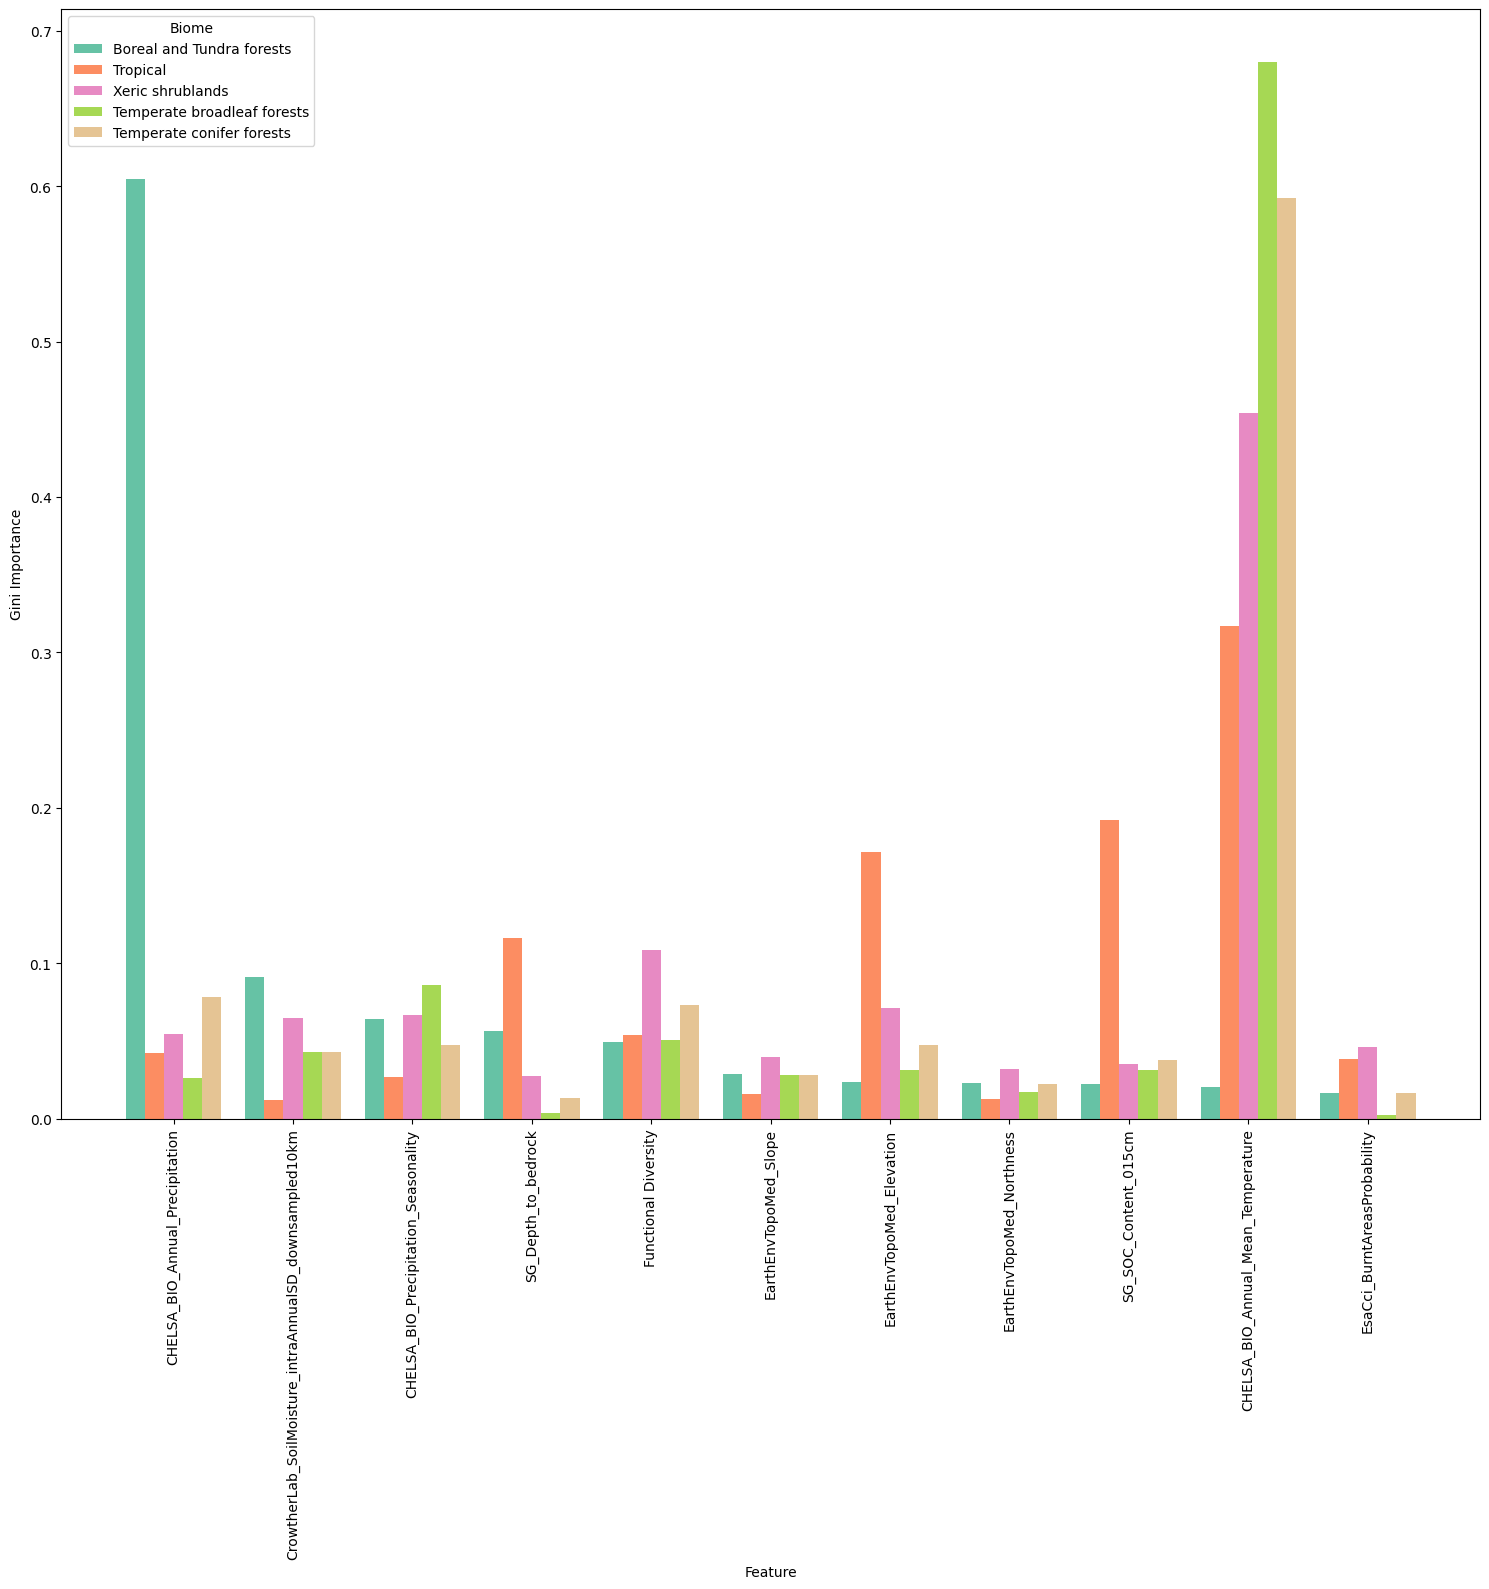

In [ ]:
diversity_df=pd.concat([func_df, spec_df], ignore_index=True)

feature = fi_df["Feature"].unique()
biomes = fi_df["biome"].unique()

x = np.arange(len(feature))
width = 0.8 / len(biomes)

cmap = plt.cm.Set2
biome_colors = {b: cmap(i / len(biomes)) for i, b in enumerate(biomes)}

fig, ax = plt.subplots(figsize=(15, 16))


for i, biome in enumerate(biomes):
    sub = fi_df[fi_df["biome"] == biome]
    
    # align values to ownership order
    y = [sub[sub["Feature"] == o]["Gini Importance"].values[0] if o in sub["Feature"].values else 0
         for o in feature]

    ax.bar(
        x + i * width,
        y,
        width=width,
        label=biome,
        color=biome_colors[biome]
    )

ax.set_xticks(x + width * (len(biomes)-1) / 2)
ax.set_xticklabels(feature, rotation=90)
ax.set_xlabel("Feature")
ax.set_ylabel("Gini Importance")
ax.legend(title="Biome")

plt.tight_layout()
plt.show()

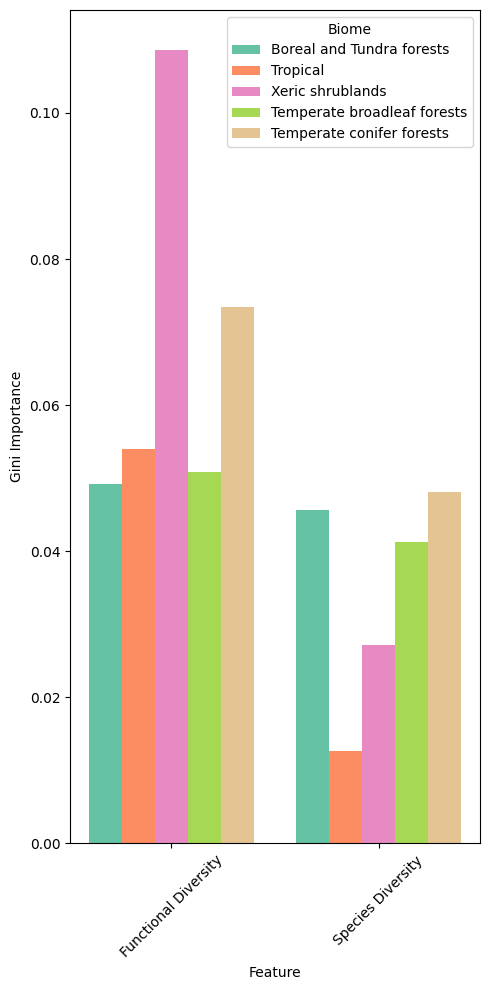

In [ ]:
import matplotlib.pyplot as plt
feature = diversity_df["Feature"].unique()
biomes = diversity_df["biome"].unique()

x = np.arange(len(feature))
width = 0.8 / len(biomes)

cmap = plt.cm.Set2
biome_colors = {b: cmap(i / len(biomes)) for i, b in enumerate(biomes)}

fig, ax = plt.subplots(figsize=(5, 10))


for i, biome in enumerate(biomes):
    sub = diversity_df[diversity_df["biome"] == biome]
    
    # align values to ownership order
    y = [sub[sub["Feature"] == o]["Gini Importance"].values[0] if o in sub["Feature"].values else 0
         for o in feature]

    ax.bar(
        x + i * width,
        y,
        width=width,
        label=biome,
        color=biome_colors[biome]
    )

ax.set_xticks(x + width * (len(biomes)-1) / 2)
ax.set_xticklabels(feature, rotation=45)
ax.set_xlabel("Feature")
ax.set_ylabel("Gini Importance")
ax.legend(title="Biome")

plt.tight_layout()
plt.show()

In [ ]:
sd_models_df=pd.read_csv("model_results_sd.csv")
fd_models_df=pd.read_csv("model_results_fd.csv")

In [ ]:
fd_models_df

,metric,npp,gc,biome
0,r2,0.422187,-0.166509,Boreal and Tundra forests
1,mae,0.310344,0.059177,Boreal and Tundra forests
2,r2,-0.112358,-0.595519,Tropical
3,mae,0.277750,0.065956,Tropical
4,r2,0.148037,-0.223826,Xeric shrublands
5,mae,0.283628,0.080598,Xeric shrublands
6,r2,0.677407,0.010717,Temperate broadleaf forests
7,mae,0.254752,0.058194,Temperate broadleaf forests
8,r2,0.295926,0.063540,Temperate conifer forests
9,mae,0.228575,0.054164,Temperate conifer forests


In [ ]:
import matplotlib.patches as mpatches

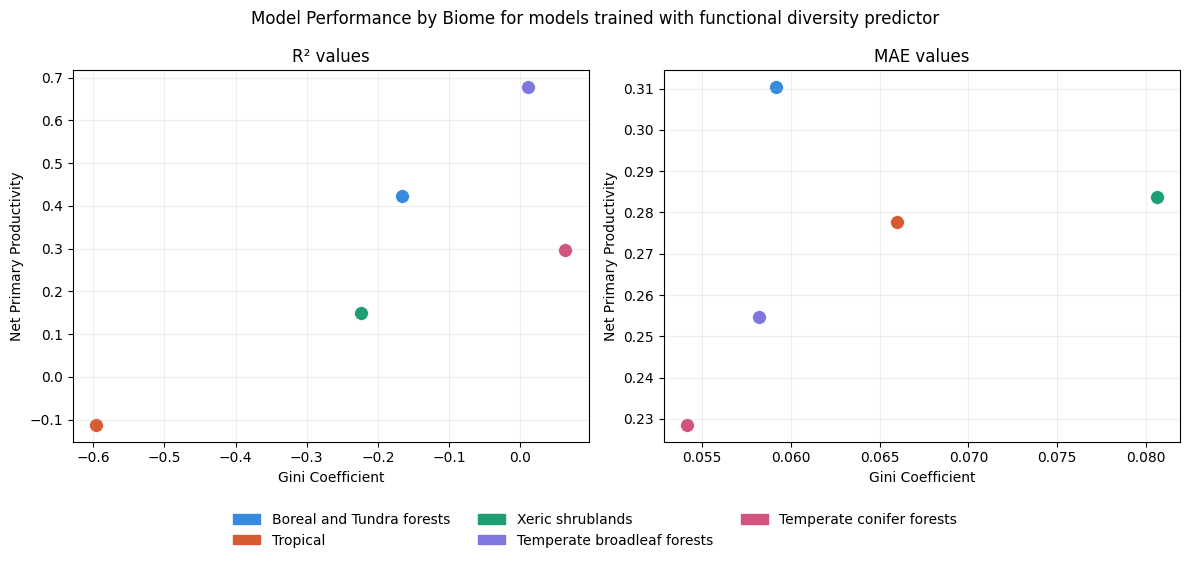

In [ ]:
biome_colors = {
    'Boreal and Tundra forests':    '#378ADD',
    'Tropical':                     '#D85A30',
    'Xeric shrublands':             '#1D9E75',
    'Temperate broadleaf forests':  '#7F77DD',
    'Temperate conifer forests':    '#D4537E',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance by Biome for models trained with functional diversity predictor', fontsize=12)

for ax, metric, title in zip(axes, ['r2', 'mae'], ['R² values', 'MAE values']):
    subset = fd_models_df[fd_models_df['metric'] == metric]
    for _, row in subset.iterrows():
        ax.scatter(row['gc'], row['npp'], color=biome_colors[row['biome']], s=100, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Gini Coefficient')
    ax.set_ylabel('Net Primary Productivity')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

legend_handles = [mpatches.Patch(color=c, label=b) for b, c in biome_colors.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()

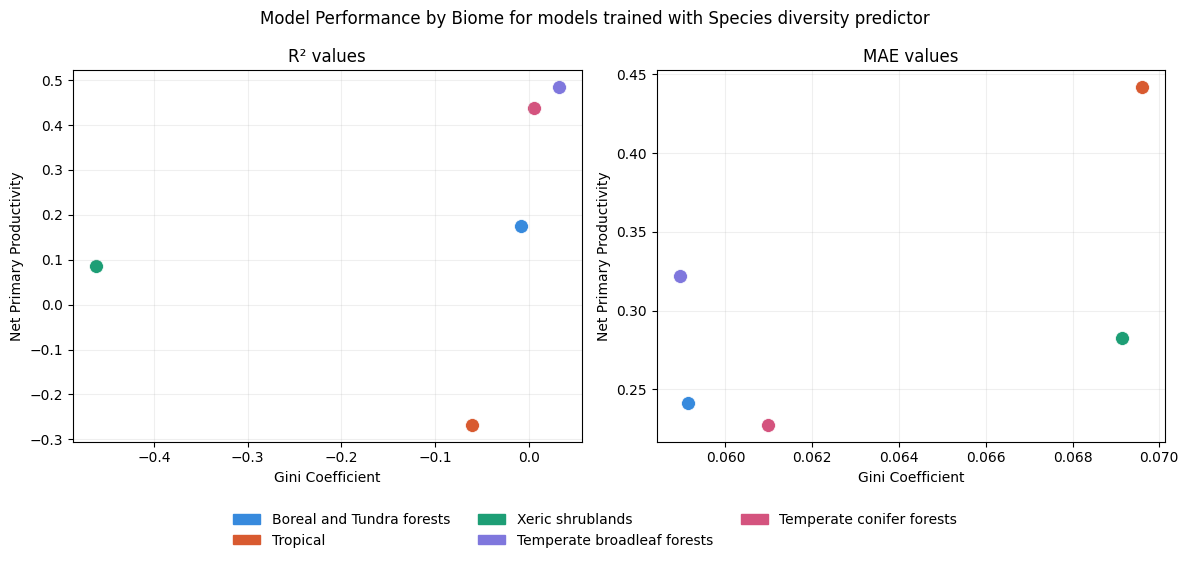

In [ ]:
biome_colors = {
    'Boreal and Tundra forests':    '#378ADD',
    'Tropical':                     '#D85A30',
    'Xeric shrublands':             '#1D9E75',
    'Temperate broadleaf forests':  '#7F77DD',
    'Temperate conifer forests':    '#D4537E',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance by Biome for models trained with Species diversity predictor', fontsize=12)

for ax, metric, title in zip(axes, ['r2', 'mae'], ['R² values', 'MAE values']):
    subset = sd_models_df[sd_models_df['metric'] == metric]
    for _, row in subset.iterrows():
        ax.scatter(row['gc'], row['npp'], color=biome_colors[row['biome']], s=100, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Gini Coefficient')
    ax.set_ylabel('Net Primary Productivity')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

legend_handles = [mpatches.Patch(color=c, label=b) for b, c in biome_colors.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()